In [1]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import time
import glob
import os

In [2]:
testDF = pd.read_csv('./overnight_run_apr1.CSV')
testDF

,timecode,seconds,lat,lat_dir,lon,lon_dir,sensor
0,260401_002748_000,1668.000,4200.0068,N,8739.5635,W,28
1,260401_002748_433,1668.433,4200.0068,N,8739.5635,W,13
2,260401_002748_532,1668.532,4200.0068,N,8739.5635,W,11
3,260401_002748_632,1668.632,4200.0068,N,8739.5635,W,12
4,260401_002748_732,1668.732,4200.0068,N,8739.5635,W,11
...,...,...,...,...,...,...,...
572411,260401_162215_600,58935.602,4159.9849,N,8739.4453,W,11
572412,260401_162215_700,58935.699,4159.9849,N,8739.4453,W,11
572413,260401_162215_800,58935.801,4159.9849,N,8739.4453,W,11
572414,260401_162215_900,58935.898,4159.9849,N,8739.4453,W,12


In [3]:
#get all unprocessed CSV files
#as practice, I made a new directory dod that had 5 copies of the same CSV file with different names
    #to use this code, change dod to uno, dos, or tres
files_CSV = glob.glob('./overnight_run_apr1.CSV', recursive=True)
#create output directory and path
output_dir = './output'
os.makedirs(output_dir, exist_ok=True)

for csv_file in files_CSV:
    print(f'Processing{csv_file}')

    #read file to create DF
    testDF = pd.read_csv(csv_file)

    #define arrays
    timecodeArr = np.array(testDF['timecode'])
    sensorArr = np.array(testDF['sensor'])
    voltageArr = sensorArr * 5/16383

    #use voltage array to define voltage DF 
    testDF['voltage'] = voltageArr
    
    #ouput filename and path of voltage values
    output_name = os.path.basename(csv_file).replace('.CSV', '_voltage.csv')
    output_path = os.path.join(output_dir, output_name)
    testDF.to_csv(output_path, index=False)
    
    print(f'Done Processing {output_path}')

print("All files processed.")

Processing./overnight_run_apr1.CSV
Done Processing ./output/overnight_run_apr1_voltage.csv
All files processed.


In [4]:
timecodeArr = np.array(testDF['timecode'])
timecodeArr
len(timecodeArr)

572416

In [5]:
sensorArr = np.array(testDF['sensor'])
sensorArr
len(sensorArr)

572416

In [6]:
timeseries = np.arange(0,57241.6,0.1)

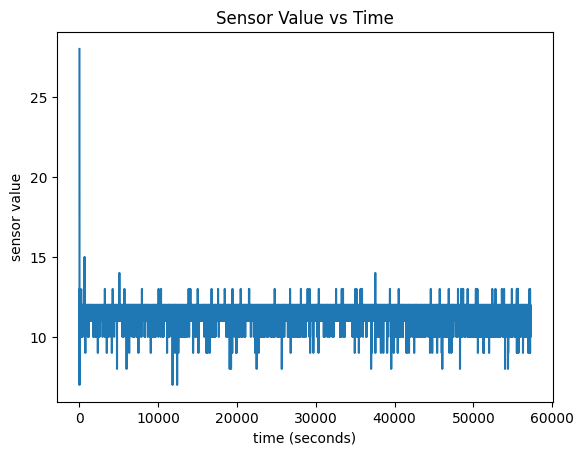

In [7]:
plt.plot(timeseries,sensorArr)
plt.title('Sensor Value vs Time')
plt.xlabel('time (seconds)')
plt.ylabel('sensor value')

plt.savefig('./output/sensor_plot.png', dpi=300, bbox_inches='tight')

In [8]:
voltageArr = sensorArr * 5/16383

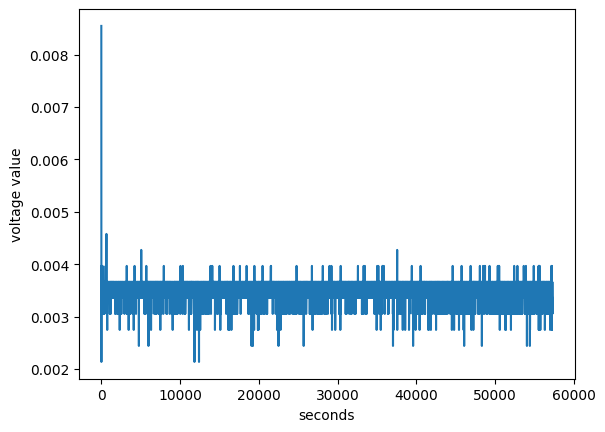

In [9]:
plt.plot(timeseries,voltageArr)
plt.xlabel('seconds')
plt.ylabel('voltage value')

plt.savefig('./output/voltage_plot.png', dpi=300, bbox_inches='tight')

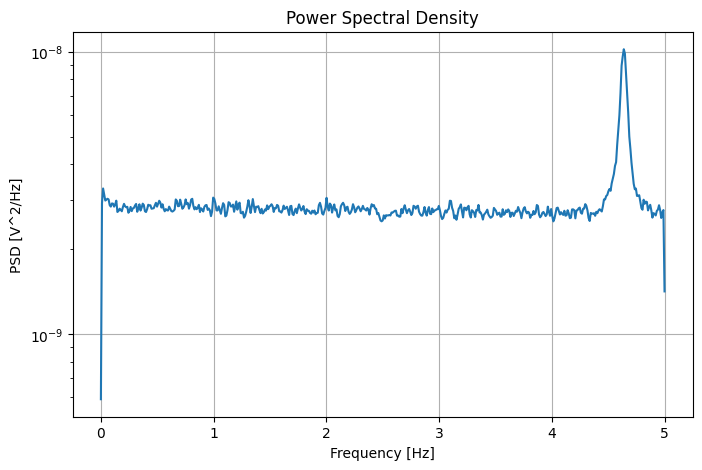

In [10]:
from scipy.signal import welch
readVoltage = pd.read_csv('./output/overnight_run_apr1_voltage.csv')
Voltage = readVoltage['voltage'].to_numpy()
fs = 10
freqs, psd = welch(Voltage, fs=fs, nperseg=1024)
plt.figure(figsize=(8,5))
plt.semilogy(freqs, psd)
plt.xlabel("Frequency [Hz]")
plt.ylabel("PSD [V^2/Hz]")
plt.title("Power Spectral Density")
plt.grid(True)
plt.show()

In [11]:
#the plot above used data from a time period when the detector was undisturbed
#we need to cut off the first and last fewseconds, as those are likely not events 
#the plot in the cell above can be used as a basis - we should cut off the first 3.5 and last 1.5 seconds 
    #can we just use these numbers to make cuts for all graphs going forward, or do we need to assume these cuts will change

#if we want something more exact, we can put something here to define 2 cuts in timecodeArr
#produce xcut_min, xcut_max
#plot including plot.xlim(xcut_min, xcut_max)

FileNotFoundError: [Errno 2] No such file or directory: '../SDCardOut/dod/graphs/voltage_xcut_plot.png'

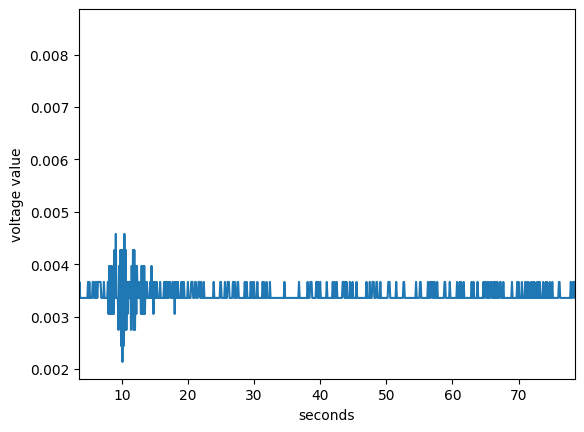

In [12]:
plt.plot(timeseries,voltageArr)
plt.xlabel('seconds')
plt.ylabel('voltage value')
plt.xlim(3.5, 78.5)
#plot.xlim(xcut_min, xcut_max)

plt.savefig('../SDCardOut/dod/graphs/voltage_xcut_plot.png', dpi=300, bbox_inches='tight')

In [ ]:
#once again, can we use this graph to define cutoff voltage? this graph consists of just background noise so we can define the cutoff at 0.065 V
#if we want to be more exact, we need to put something here to define a cutoff for each voltageArr

#2 ways to look at the signals and background
#option 1: produce a graph of only voltages below ycutoff ---> this is the background voltage  plot
#          produce a graph of only voltages above ycutoff ---> this is the events voltage plot
#option 1 is shown below
#option 2: produce a graph with a line representing ycutoff. I do not want to do this until I have a way to define cutoff voltage.
    #i just havent done this yet

In [ ]:
plt.plot(timeseries,voltageArr)
plt.xlim(5, 78)
plt.ylim(0, 0.065)
#plt.ylim(0, ycutoff)
plt.title('background noise cutoff')
plt.xlabel('seconds')
plt.ylabel('voltage value')

plt.savefig('../SDCardOut/dod/graphs/background_voltage_cut_plot.png', dpi=300, bbox_inches='tight')

In [ ]:
plt.plot(timeseries,voltageArr)
plt.xlim(5, 78)
plt.ylim(0.065, 0.1)
#plt.ylim(ycutoff, ymax 0.3)
plt.title('train event cutoff')
plt.xlabel('time seconds')
plt.ylabel('voltage value')

plt.savefig('../SDCardOut/dod/graphs/events_voltage_cut_plot.png', dpi=300, bbox_inches='tight')

In [ ]:
freqpsd10,powpsd10 = sp.signal.welch(sensorArr,fs=10,nperseg=10)
freqpsd50,powpsd50 = sp.signal.welch(sensorArr,fs=10,nperseg=50)
freqpsd100,powpsd100 = sp.signal.welch(sensorArr,fs=10,nperseg=100)
freqpsd500,powpsd500 = sp.signal.welch(sensorArr,fs=10,nperseg=500)

In [ ]:
plt.plot(freqpsd10,powpsd10,label="window 1s")
plt.plot(freqpsd50,powpsd50,label="window 5s")
plt.plot(freqpsd100,powpsd100,label="window 10s")
plt.plot(freqpsd500,powpsd500,label="window 50s")
plt.xlabel('frequency (Hz)')
plt.ylabel("power")
plt.legend()
plt.semilogy()

In [ ]:
#ok